# Task 2.1 — Neural Network in PyTorch

## Fashion-MNIST Image Classification

This notebook implements a feed-forward neural network using PyTorch.

The workflow includes:
- Tensors
- Dataset and DataLoader
- Neural Network
- Loss Function
- Optimizer
- Model Training
- Model Evaluation

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
print("PyTorch version:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

PyTorch version: 2.11.0+cpu
Device: cpu


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 278kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.05MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.5MB/s]

Training samples: 60000
Testing samples: 10000


In [ ]:
classes = train_dataset.classes

print(classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


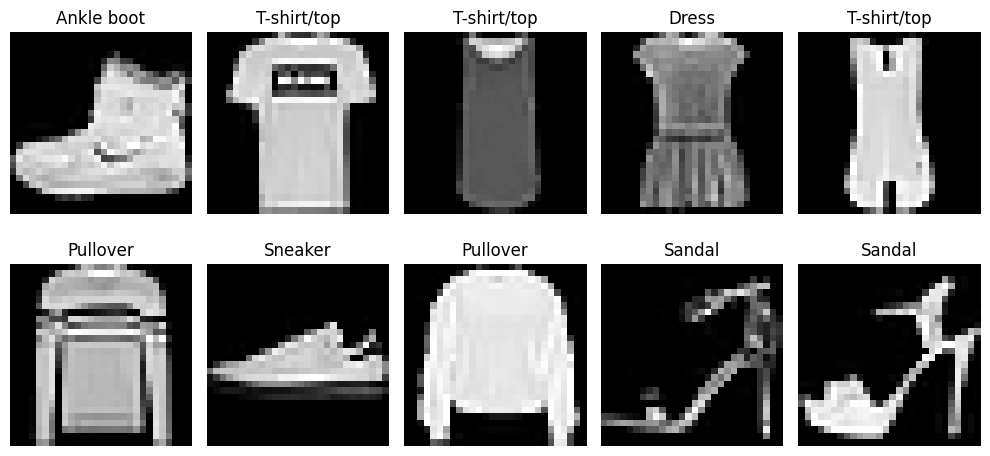

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):

    image, label = train_dataset[i]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Number of training batches:", len(train_loader))
print("Number of testing batches:", len(test_loader))

Number of training batches: 938
Number of testing batches: 157


In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


In [ ]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):

        x = self.flatten(x)

        return self.network(x)


model = NeuralNetwork().to(device)

print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
num_epochs = 10

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/10], Loss: 0.5208
Epoch [2/10], Loss: 0.3810
Epoch [3/10], Loss: 0.3428
Epoch [4/10], Loss: 0.3179
Epoch [5/10], Loss: 0.2990
Epoch [6/10], Loss: 0.2855
Epoch [7/10], Loss: 0.2713
Epoch [8/10], Loss: 0.2567
Epoch [9/10], Loss: 0.2470
Epoch [10/10], Loss: 0.2381


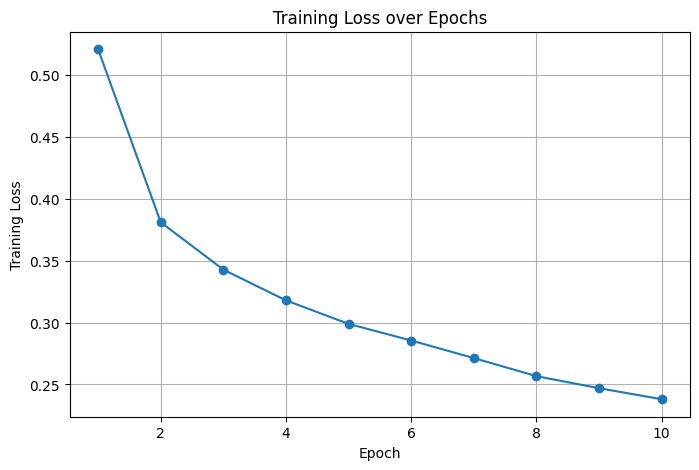

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)

plt.show()

In [ ]:
model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 88.31%


In [ ]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=classes
    )
)

              precision    recall  f1-score   support

 T-shirt/top       0.81      0.87      0.84      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.83      0.79      0.81      1000
       Dress       0.86      0.91      0.89      1000
        Coat       0.79      0.82      0.81      1000
      Sandal       0.98      0.93      0.96      1000
       Shirt       0.74      0.66      0.70      1000
     Sneaker       0.93      0.94      0.94      1000
         Bag       0.98      0.96      0.97      1000
  Ankle boot       0.92      0.97      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



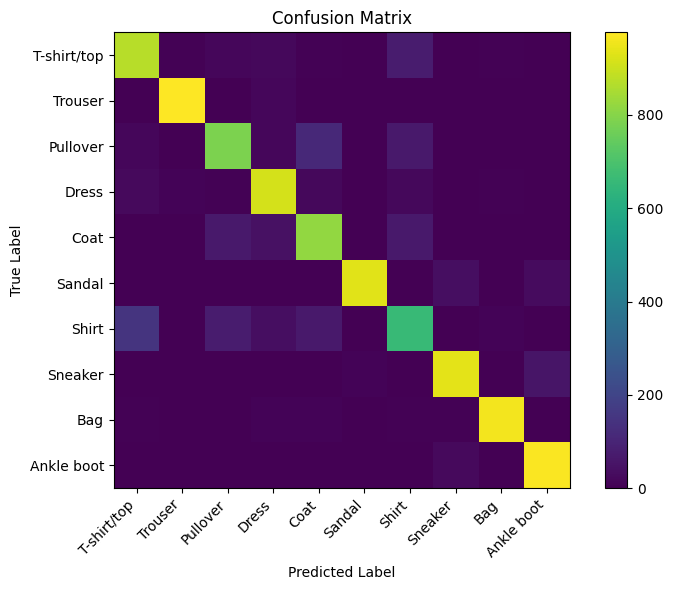

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.xticks(
    range(len(classes)),
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.tight_layout()
plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "fashion_mnist_mlp.pth"
)

print("Model saved successfully.")

Model saved successfully.


## Conclusion

A feed-forward neural network was implemented using PyTorch
for Fashion-MNIST image classification.

The implementation included:
- PyTorch tensors
- Dataset and DataLoader
- Feed-forward neural network
- Cross-entropy loss
- Adam optimizer
- Model training
- Test-set evaluation
- Classification metrics
- Confusion matrix

The final test accuracy was recorded and will be used as a
baseline for comparison with the CNN model in Task 2.2.
The MLP achieved a test accuracy of 88.00% on the Fashion-MNIST dataset.